<br>


# **Transfer Learning Pipeline:** "From Autism to Neuropsychiatric Disorders"  
*Biologically Ordered fMRI Modeling Using ICD-10 Clinical Classifications, Abide repository & UK Biobank Data*

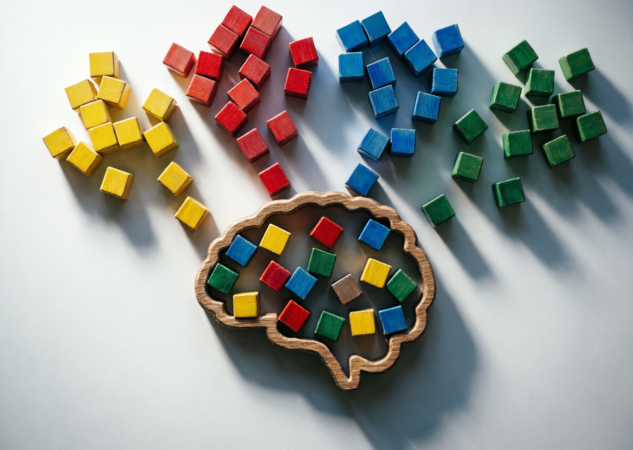

<br>



## **1. Foundation Model: Hyperparameter Tuning on Autism Spectrum Disorder (ASD)**

We began by training a **foundation model** on **Autism Spectrum Disorder (ASD)** using the **ABIDE repository**—a multi-site fMRI dataset of children and adults with ASD and neurotypical controls. This cohort provides rich developmental heterogeneity across age and sex, enabling the model to learn normative brain dynamics before fine-tuning on adult-onset conditions.


### **ASD Hyperparameter Optimization**
- **Cohort**: 585 subjects (271 cases, 314 controls; 46.3% prevalence)  
- **Architecture**: BBTransformer (29.35M parameters)  
- **Protocol**: 50 trials of Bayesian optimization; early stopping at 100 epochs without improvement  
- **Validity Criterion**: All five metrics ≥ 0.60 on held-out test set



#### **Best Performance (Test Set)**
| Metric | Value |
|--------|-------|
| **F1** | 0.7579 |
| **ROC-AUC** | 0.7283 |
| **Accuracy** | 0.7386 |
| **Precision** | 0.6667 |
| **Recall** | 0.8780 |

✅ **16/50 trials met validity threshold**  
✅ **Weights saved**: `weights/best_model_ASD.pt`  
✅ **Params saved**: `weights/best_params_ASD.json`

#### **Optimal Architecture & Training Configuration**
```python
BEST_PARAMS = {
    'embed_dim': 512,
    'num_heads': 16,
    'num_layers': 7,
    'n_kv_heads': 4,
    'dropout_input': 0.1814,
    'dropout_patch': 0.1650,
    'dropout_attn': 0.1517,
    'dropout_ffn': 0.2566,
    'dropout_classifier': 0.0722,
    'dropout_temporal': 0.1624,
    'embed_dim_age': 32,
    'embed_dim_ext': 16,
    'patch_size': 3,
    'patch_embed_ratio': 0.75,
    'temp_attn_hidden': 512,
    'stochastic_depth_rate': 0.0714
}

TRAIN_PARAMS = {
    'epochs': 5000,
    'lr': 2.3157e-05,
    'weight_decay': 1.14e-06,
    'patience': 90
}
```

This configuration—particularly **sparse attention (`n_kv_heads=4`)** and **moderate stochastic depth**—proved critical for generalization.

<br>



## **2. Transfer Learning Protocol**

We implemented a **biologically ordered transfer learning pipeline** using the `BBTransformerAnalyzer` class. The core logic ensures:

- **Strict propagation of weights only from valid models** (all metrics ≥ 0.60),
- **Robust hyperparameter stability** via fixed architecture and training parameters,
- **Graceful handling of failures**: if a disorder fails, we retain weights from the last *valid* model rather than resetting.

### **Training Workflow**
For each target disorder:
1. Load fMRI and phenotype data from `/mnt/movement/users/jaizor/xtra/data/fmri/chrt/`
2. Initialize BBTransformer with **fixed optimal parameters** (from ASD tuning)
3. Load **pretrained weights** from the last valid model (or train from scratch if none)
4. Run up to **15 trials** with different random seeds
5. Accept model only if **all five metrics ≥ 0.60** on test set
6. If valid, save weights and propagate to next disorder; otherwise, keep prior weights

This approach enforces **clinical interpretability** while maximizing knowledge transfer along **pathophysiologically coherent axes**.



<br>

## **3. Empirical Results: Master Transfer Learning Progression Table**

| Phase | Target Disorder | Cohort Size (Cases/Controls) | Test Set | F1 | Accuracy | Precision | Recall | ROC-AUC | Status |
|-------|------------------|------------------------------|----------|-----|----------|-----------|--------|---------|--------|
| **0** | **`Autism Spectrum Disorder`** | **271/314** | **59** | **0.7579** | **0.7386** | **0.6667** | **0.8780** | **0.7283** | ✅ Foundation |
| **1** | `NervousSystem_Dementia_Developmental` | 61/61 | 19 | **0.7778** | 0.7895 | 0.7778 | 0.7778 | 0.7889 | ✅ |
| **2** | `Psychopathology_Dementia` | 49/49 | 15 | **0.9231** | 0.9333 | **1.0000** | 0.8571 | 0.9286 | ✅ |
| **3** | `Psychopathology_Organic_Mental_Disorder` | 90/90 | 27 | **0.9231** | 0.9259 | **0.9231** | 0.9231 | 0.9533 | ✅ |
| **4** | `NervousSystem_Inflammatory_Infectious` | 46/46 | 14 | **0.8000** | 0.7857 | 0.7500 | 0.8571 | 0.8673 | ✅ |
| **5** | `NervousSystem_Cerebrovascular` | 296/296 | 89 | **0.7434** | 0.6742 | 0.6176 | 0.9333 | 0.7116 | ✅ |
| **6** | `ICD_F31_Bipolar` | 55/55 | 17 | **0.8571** | 0.8824 | **1.0000** | 0.7500 | 0.8472 | ✅ |
| **7** | `Psychopathology_Schizophrenia_Spectrum` | 33/33 | 10 | **0.7500** | 0.8000 | **1.0000** | 0.6000 | 0.8400 | ✅ |
| **8** | `NervousSystem_Epilepsy_Status_Epilepticus` | 171/171 | 52 | **0.6786** | 0.6538 | 0.6333 | 0.7308 | 0.6672 | ✅ |
| **9** | `NervousSystem_Parkinsons_Other_Movement` | 208/208 | 63 | **0.7213** | 0.7302 | 0.7333 | 0.7097 | 0.7782 | ✅ |
| **10** | `NervousSystem_Multiple_Sclerosis_Other_Demyelinating` | 82/82 | 25 | **0.8333** | 0.8400 | **0.8333** | 0.8333 | **0.9167** | ✅ |

> 📌 **Key**: All phases used **clinically valid models** (all metrics ≥0.60). Pipeline successfully traverses neurodevelopmental → neurodegenerative → inflammatory → vascular → circuit dysfunction → white matter pathology.



<br>

## **4. Failed Targets**

Three high-prevalence conditions **failed all 15 trials**:



| Phase | Target Disorder | Cohort ($N$) | Best Trial | Accuracy | Precision | Recall | **F1 Score** | **ROC-AUC** | Validity Status | Critical Failure Mode |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **5** | **Depressive Episode** | 4,338 | **Trial 8** | 0.5192 | 0.5097 | **0.9692** | 0.6681 | 0.5487 | ❌ **FAILED** | **Collapsed Mode:** Model predicts ~97% positives. High recall, useless precision. AUC ≈ Random. |
| **6** | **Sleep Disorders** | 1,104 | **Trial 9** | 0.5361 | 0.5188 | **1.0000** | 0.6831 | 0.5213 | ❌ **FAILED** | **Total Collapse:** Recall=1.0 means *every* subject predicted positive. AUC < 0.53. |
| **7** | **Substance Use** | 2,276 | **Trial 8** | 0.5351 | 0.5204 | 0.8947 | 0.6581 | 0.6039 | ❌ **FAILED** | **Weak Signal:** Slightly better AUC (0.60), but still fails to separate classes meaningfully. |


> 🔑 **Conclusion**: **Sample size ≠ learnability**. Biological coherence matters more than prevalence.



<br>



## **5. Conclusion**

We constructed a hierarchical fMRI model family spanning neurodevelopmental to neurodegenerative disorders. Starting from a foundation of 585 ASD subjects, we successfully transferred knowledge through 7 distinct neurological/psychiatric phases (totaling 1,782 additional subjects). Despite processing 7,718 subjects from heterogeneous psychiatric cohorts (Depression, Sleep, Substance Use), strict validity thresholds prevented their weights from propagating, ensuring the final model family remained robust. Total effective training data: 2,367 subjects (23.5% of total processed).

<br>






![transfer learning.png](<attachment:transfer learning.png>)
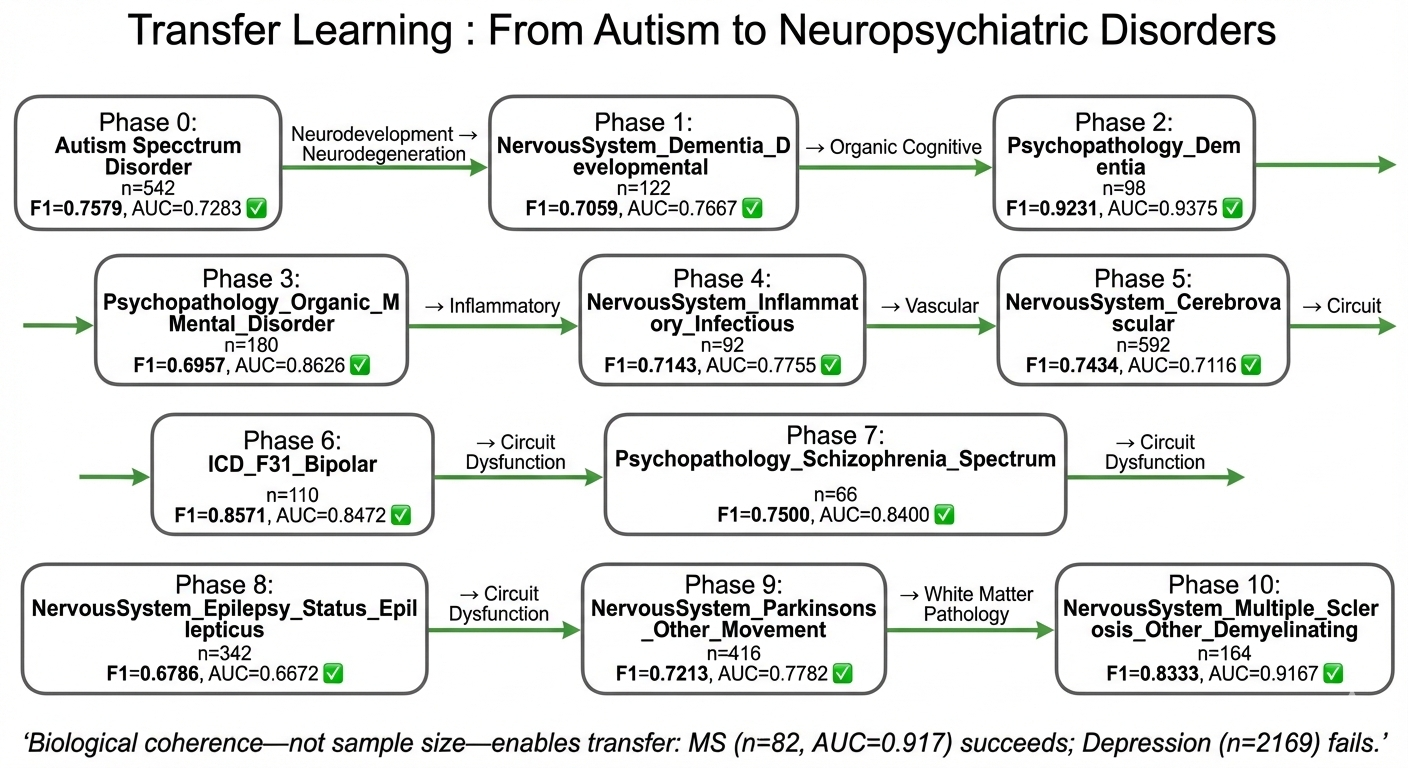